# Swin Transformer V2-Base

## Import

In [1]:
import os  
os.environ['KMP_DUPLICATE_LIB_OK']='True' # fix dead kernel

In [2]:
import albumentations as A
import timm
import torch
import torch.nn as nn
import torch.optim as optim

from albumentations.pytorch import ToTensorV2
from torchvision import models

/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/lib/python3.10/site-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Load Model

In [3]:
import ssl
import certifi
import urllib.request

# Set the default SSL context to use the  certificate bundle
ssl._create_default_https_context = ssl._create_unverified_context

# Alternatively, you can set the context for urllib globally
context = ssl.create_default_context(cafile=certifi.where())
opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=context))
urllib.request.install_opener(opener)

num_classes = 4
device = "cuda" if torch.cuda.is_available() else "cpu"

model_name = "swinv2_base_window12to16_192to256.ms_in22k_ft_in1k"  

net = timm.create_model(
    model_name,
    pretrained=True,
    num_classes=num_classes,
    drop_rate=0.0,       
    drop_path_rate=0.0,   
).to(device)

## Prepare the Dataset

### Load Training/Testing Datasets

In [4]:
from pathlib import Path
from collections import Counter
from data_augmentation import cnn_only_augmentation

train_directory = Path(r"/scratch/user/al63rt.tran/Train")
validation_directory = Path(r"/scratch/user/al63rt.tran/Validation")

class_names = ["Uninhabited", "Empty", "Rebuilding", "Rebuilt"]

class_sampling = {
    "Uninhabited": "all",
    "Rebuilding": "all",
    "Empty": 800,
    "Rebuilt": 800,
}

augmentation_factors = {
    "Uninhabited": 8,
    "Rebuilding": 5,
}

### Set Up Training Dataset

In [5]:
from train_utils import (
    _build_address_list,
    build_train_loader,
    train_model,
    _live_plot,
)

train_folders = sorted([p for p in train_directory.iterdir() if p.is_dir()])

train_addrs = []
for folder in train_folders:
    addrs_i, class_names_i = _build_address_list(str(folder), class_names=class_names)
    train_addrs.extend(addrs_i)

meta = {
    "train_addrs": train_addrs,
}

print("Train folders:", [p.name for p in train_folders])

Train folders: ['.ipynb_checkpoints', 'Train 2011', 'Train 2012', 'Train 2013', 'Train 2014', 'Train 2015', 'Train 2016']


### Set Up Validation Dataset

In [6]:
minority_aug, base = cnn_only_augmentation()

augmentation_ds = {
    "aug_t": minority_aug,
    "base_t": base,
}

In [7]:
validation_loader = None

if validation_directory.exists():
    validation_folders = sorted([p for p in validation_directory.iterdir() if p.is_dir()])
    validation_addrs = []

    for folder in validation_folders:
        addrs_i, _ = _build_address_list(str(folder), class_names=class_names)
        validation_addrs.extend(addrs_i)

    validation_meta = {
        "train_addrs": validation_addrs,
        "train_pairs": [(i, False) for i in range(len(validation_addrs))],
    }

    validation_loader = build_train_loader(
        augmentation_ds=augmentation_ds,
        meta=validation_meta,
        batch_size=1,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        max_frames=64,
    )

    print("Validation folders:", [p.name for p in validation_folders])

Validation folders: ['.ipynb_checkpoints', 'Validation 2011', 'Validation 2012', 'Validation 2013', 'Validation 2014', 'Validation 2015', 'Validation 2016']


### Hyperparameters Setting

In [8]:
optimizer = torch.optim.AdamW(
    net.parameters(),
    lr=1e-5,
    weight_decay=1e-3,
)

lr = [1e-5, 1e-6]
lr_epochs = [1, 25]   

### Implement Training

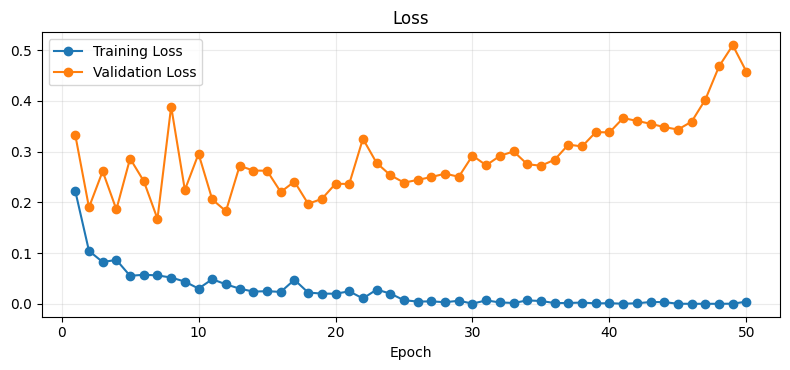

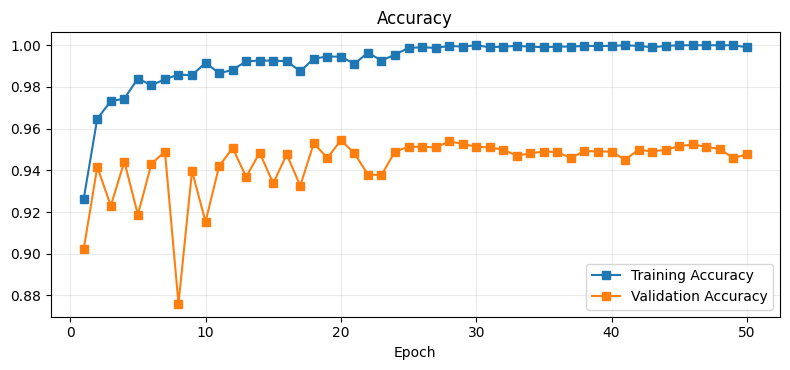

In [10]:
# Set training information directory
csv_path = r"/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/designsafe/swinv2.csv"

history = train_model(
    model=net,
    epochs=50,
    optimizer=optimizer,
    mode="single",
    lr=lr,
    lr_epochs=lr_epochs,
    device="cuda" if torch.cuda.is_available() else "cpu",
    colour="green",
    validation_loader=validation_loader,
    csv_path=csv_path,
    checkpoint_dir=r"/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/designsafe/swinv2",
    checkpoint_prefix="swinv2",
    freeze_bn=True,
    plot_fn=_live_plot,
    class_sampling=class_sampling,
    augmentation_factors=augmentation_factors,
    augmentation_ds=augmentation_ds,
    meta=meta,
    class_names=class_names,
    seed=42,
    dropout_p=0.2,
    apply_dropout=True,
)

## Restore Best Model

In [9]:
device = "cuda" if torch.cuda.is_available() else "cpu"

path = Path("/scratch/user/al63rt.tran/my_envs/my_notebook-python-3.10.4/swinv2/swinv2_epoch_018.pth")

ckpt = torch.load(path, map_location=device)

# get actual weights
state_dict = ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt

# if saved with DataParallel, remove "module." prefix
if len(state_dict) > 0 and next(iter(state_dict)).startswith("module."):
    state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

net = net.to(device)
net.load_state_dict(state_dict, strict=True)
net.eval()

print("Loaded epoch:", ckpt.get("epoch"))
print("Validation loss:", ckpt.get("validation_loss"))

Loaded epoch: 18
Validation loss: 0.1972260429451148


## Evaluate Performance

### Plot Confusion Matrix

In [10]:
from confusion_single import confusion_matrix

  0%|          | 0/3532 [00:00<?, ?it/s]

              precision    recall  f1-score   support

 Uninhabited      0.906     0.941     0.923        51
       Empty      0.915     0.952     0.933       993
  Rebuilding      0.688     0.667     0.677        66
     Rebuilt      0.978     0.962     0.970      2422

    accuracy                          0.953      3532
   macro avg      0.871     0.880     0.876      3532
weighted avg      0.954     0.953     0.953      3532

Saved confusion matrix to: /scratch/user/al63rt.tran/cm_swinv2.png


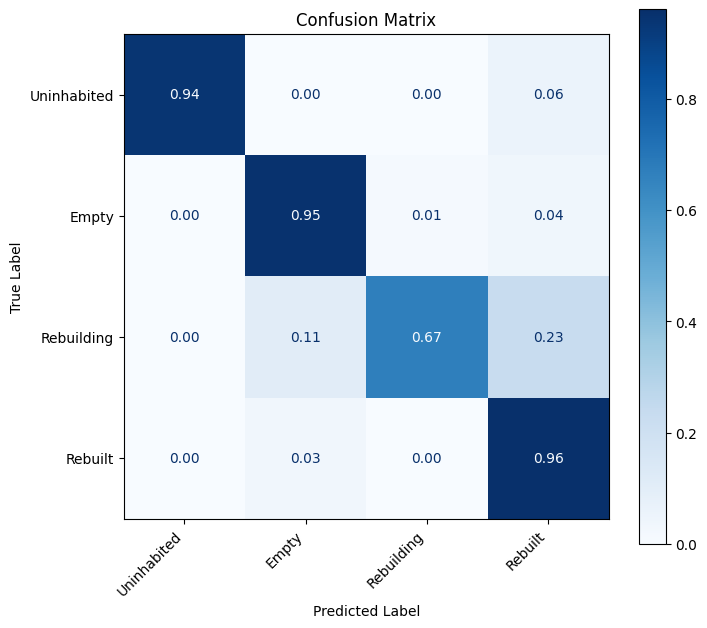

In [12]:
cm, cm_norm = confusion_matrix(
    model=net,
    loader=validation_loader,
    class_names=class_names,
    device="cuda",
    cmap="Blues",
    save_path="/scratch/user/al63rt.tran/cm_swinv2.png",
    dpi=300,
)